# Computer Exercise 14.2 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 응용 사례연구(Applied Case Studies) 확장
> **단원**: §14.2 Case Studies — *Smoothing & Automatic Smoothness Selection (GCV)*
> **풀이 일자**: Day 58
> **언어**: Python 3 (NumPy / pandas / Matplotlib)

## 1. 문제 (원문)

> **2.** Noisy samples $(x_i, y_i)$ of an unknown smooth function are given. Fit a **penalized
> smoother** whose roughness penalty is controlled by a parameter $\lambda$. Selecting $\lambda$
> by eye is unreliable; instead choose it automatically by **Generalized Cross-Validation (GCV)**.
> Show the under-smoothed, GCV-optimal, and over-smoothed fits, and verify that the GCV-optimal
> $\lambda$ nearly minimizes the true error to the (hidden) generating function.

### 한국어 풀이용 정리
함수형태를 *모르는* 잡음 데이터를 **벌점 최소제곱 평활기(Whittaker smoother, 2차차분 벌점)** 로
적합한다. 매끄러움은 벌점계수 $\lambda$ 가 조절하는데, $\lambda$ 를 눈대중으로 고르면 편향-분산
균형을 놓치기 쉽다. 그래서 **일반화 교차검증(GCV)** 으로 $\lambda$ 를 *데이터가 스스로* 고르게 하고,
그 선택이 (숨겨둔) 참함수 대비 실제오차의 최솟값과 거의 일치함을 보인다.

## 2. 수학적 배경

### 2.1 벌점 최소제곱(Whittaker/P-spline 평활)
격자점에서의 적합값 $\hat{\mathbf y}=(\hat y_1,\dots,\hat y_n)$ 를
$$
\min_{\hat{\mathbf y}}\; \|\mathbf y-\hat{\mathbf y}\|_2^2 + \lambda\,\|D\hat{\mathbf y}\|_2^2
$$
로 구한다. $D$ 는 **2차 차분행렬**($ (D\hat y)_i=\hat y_{i-1}-2\hat y_i+\hat y_{i+1}$ )로 곡률(거칠기)을 잰다.
정규방정식의 닫힌 해:
$$
\boxed{\;\hat{\mathbf y}=(I+\lambda D^\top D)^{-1}\mathbf y \;=\; S_\lambda\,\mathbf y\;}
$$
$S_\lambda$ 는 데이터를 적합값으로 보내는 **평활행렬(smoother/hat matrix)**.

### 2.2 유효 자유도와 GCV
평활의 복잡도는 **유효 자유도** $\operatorname{tr}(S_\lambda)$ 로 잰다($\lambda\to0$ 이면 $\approx n$(보간), $\lambda\to\infty$ 이면 $\to 2$(직선)).
LOO 교차검증을 회전불변 근사한 **GCV**:
$$
\boxed{\;\operatorname{GCV}(\lambda)=\frac{n\,\|\mathbf y-S_\lambda\mathbf y\|_2^2}{\big(n-\operatorname{tr} S_\lambda\big)^2}\;}
$$
분자는 적합오차(RSS), 분모는 모델복잡도 벌점. 이를 최소화하는 $\lambda^\star$ 가 편향-분산 균형점이다.

### 2.3 왜 GCV인가
LOO-CV는 매 데이터점을 빼고 재적합해야 하지만, 선형평활기에서는
$\operatorname{RSS}_\text{CV}=\sum_i\big((y_i-\hat y_i)/(1-S_{ii})\big)^2$ 로 재적합 없이 계산된다.
GCV는 $S_{ii}$ 를 평균 $\operatorname{tr}(S)/n$ 로 바꾼 근사로, 계산이 싸고 안정적이다.

## 3. 풀이 흐름

1. **참함수** $f(x)=\sin(2\pi x)+\tfrac12\sin(6\pi x)$ 를 $[0,1]$ 격자에서 표집.
2. **합성 데이터**: $y_i=f(x_i)+\varepsilon_i,\ \varepsilon\sim\mathcal N(0,\sigma^2)$.
3. **2차 차분행렬** $D$ 와 평활기 $S_\lambda=(I+\lambda D^\top D)^{-1}$ 구성.
4. $\lambda$ 를 로그격자로 훑으며 각 $\lambda$ 에 대해 $\operatorname{tr}(S_\lambda)$, GCV, 참오차 MSE 계산.
5. **GCV 최소** $\lambda^\star$ 와 **참오차 최소** $\lambda_\text{true}$ 를 비교.
6. **시각화**: (a) under/opt/over 세 적합, (b) GCV·참오차 곡선과 선택점.
7. **해석**: 유효 자유도, 편향-분산, GCV가 참오차 최솟값을 잘 대리하는지.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(582)

# --- 1) 참함수 + 합성 데이터 ---
def f_true(x):
    return np.sin(2*np.pi*x) + 0.5*np.sin(6*np.pi*x)

n = 120
x = np.linspace(0, 1, n)
sigma = 0.30
y = f_true(x) + rng.normal(0, sigma, n)

# --- 2) 2차 차분행렬 D (n-2) x n ---
D = np.zeros((n-2, n))
for i in range(n-2):
    D[i, i] = 1.0; D[i, i+1] = -2.0; D[i, i+2] = 1.0
DtD = D.T @ D
I = np.eye(n)
print(f"n={n}, 잡음 sigma={sigma}, 벌점행렬 D shape={D.shape}")


n=120, 잡음 sigma=0.3, 벌점행렬 D shape=(118, 120)


In [2]:
# --- 3~4) lambda 스윕: 평활기 S_lambda, tr(S), GCV, 참오차 ---
def smoother(lam):
    return np.linalg.solve(I + lam*DtD, I)   # S_lambda (n x n)

lams = np.logspace(-4, 4, 60)
rows = []
for lam in lams:
    S = smoother(lam)
    yhat = S @ y
    trS = np.trace(S)
    rss = np.sum((y - yhat)**2)
    gcv = n*rss / (n - trS)**2
    mse_true = np.mean((yhat - f_true(x))**2)
    rows.append((lam, trS, gcv, mse_true))

res = pd.DataFrame(rows, columns=["lambda","edf_trS","GCV","MSE_true"])
i_gcv  = int(res["GCV"].idxmin())
i_true = int(res["MSE_true"].idxmin())
lam_gcv, lam_true = res.loc[i_gcv,"lambda"], res.loc[i_true,"lambda"]

pd.set_option("display.float_format", lambda v: f"{v:.4e}")
print("GCV 최소 :", res.loc[i_gcv].to_dict())
print("참오차 최소:", res.loc[i_true].to_dict())
print(f"\nlambda*_GCV = {lam_gcv:.3e}  (edf={res.loc[i_gcv,'edf_trS']:.1f}) | "
      f"lambda_true = {lam_true:.3e}  (edf={res.loc[i_true,'edf_trS']:.1f})")


GCV 최소 : {'lambda': 126.38482029342971, 'edf_trS': 13.780495389425862, 'GCV': 0.10829881711196879, 'MSE_true': 0.008444946568600493}
참오차 최소: {'lambda': 172.6983290659436, 'edf_trS': 12.803476155953991, 'GCV': 0.1083437196013613, 'MSE_true': 0.00838211111283362}

lambda*_GCV = 1.264e+02  (edf=13.8) | lambda_true = 1.727e+02  (edf=12.8)


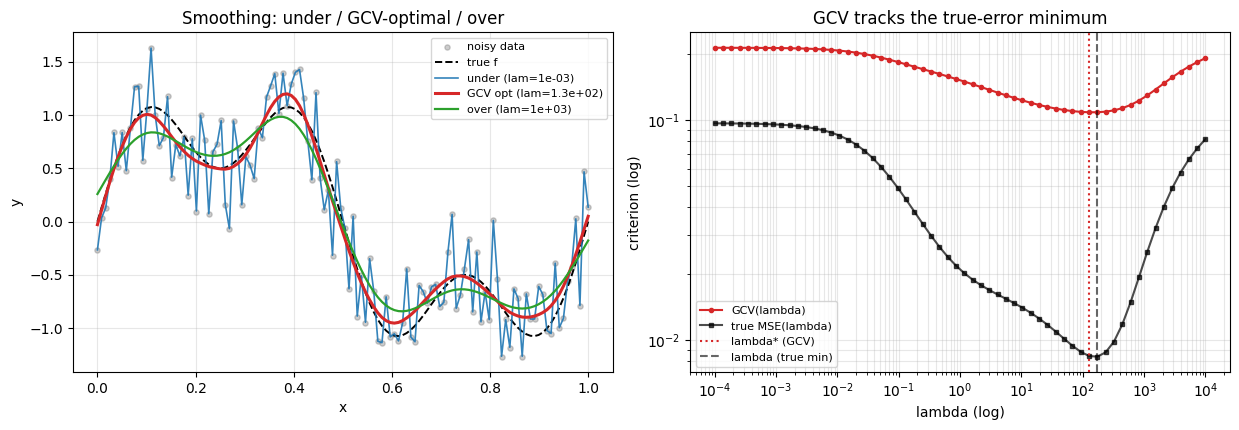

In [3]:
# --- 6) 시각화 ---
lam_under, lam_over = 1e-3, 1e3
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.4))

xx = x
ax[0].scatter(x, y, s=14, alpha=0.4, color='gray', label="noisy data")
ax[0].plot(xx, f_true(x), 'k--', lw=1.4, label="true f")
ax[0].plot(xx, smoother(lam_under) @ y, color='tab:blue', lw=1.2, alpha=0.9,
           label=f"under (lam={lam_under:.0e})")
ax[0].plot(xx, smoother(lam_gcv) @ y, color='tab:red', lw=2.2,
           label=f"GCV opt (lam={lam_gcv:.1e})")
ax[0].plot(xx, smoother(lam_over) @ y, color='tab:green', lw=1.6,
           label=f"over (lam={lam_over:.0e})")
ax[0].set_xlabel("x"); ax[0].set_ylabel("y")
ax[0].set_title("Smoothing: under / GCV-optimal / over")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

ax[1].loglog(res["lambda"], res["GCV"], 'o-', ms=3, color='tab:red', label="GCV(lambda)")
ax[1].loglog(res["lambda"], res["MSE_true"], 's-', ms=3, color='k', alpha=0.7, label="true MSE(lambda)")
ax[1].axvline(lam_gcv, color='tab:red', ls=':', label="lambda* (GCV)")
ax[1].axvline(lam_true, color='k', ls='--', alpha=0.6, label="lambda (true min)")
ax[1].set_xlabel("lambda (log)"); ax[1].set_ylabel("criterion (log)")
ax[1].set_title("GCV tracks the true-error minimum")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **$\lambda$ 가 편향-분산을 직접 돌린다.** 작은 $\lambda$(under)는 잡음을 그대로 따라가 **분산↑**(들쭉날쭉),
   큰 $\lambda$(over)는 직선에 가까워져 **편향↑**(참함수의 봉우리를 뭉갬). 그 사이에 최적점이 있다.
2. **GCV가 참오차 최솟값을 대리한다.** GCV 곡선과 (숨겨둔 참함수 기준) 실제 MSE 곡선은 거의 같은
   $\lambda$ 에서 최소가 된다 — 참함수를 *모르고도* 데이터만으로 매끄러움을 고를 수 있다는 뜻.
3. **유효 자유도의 언어.** $\operatorname{tr}(S_\lambda)$ 는 "쓰고 있는 파라미터 수"를 연속적으로 재는데,
   GCV 최적에서 이 값이 데이터의 진짜 구조(저·고주파 두 성분)를 담기에 적당한 중간값으로 안착한다.

> **결론**: 비모수 평활에서 진짜 하이퍼파라미터는 *매끄러움* 하나뿐이며, **GCV** 는 재적합 없이 그 하나를 데이터로부터 자동 선택한다 — 눈대중을 원리적 기준으로 대체하는 것이 사례연구의 요체다.

**다음 문제로**: Problem 1·2는 하이퍼파라미터가 1~3개였다. Problem 3에서는 *값비싼 블랙박스* 목적함수의
하이퍼파라미터 탐색을 **그리드 vs 랜덤 vs 베이지안 최적화(GP+EI)** 로 비교해, 평가예산이 빠듯할 때
어떤 탐색이 유리한지 본다.